In [ ]:
# Import the necessary libraries for data handling, machine learning and visualisation
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, recall_score
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE


In [ ]:
# Load the diabetes dataset in the form of a CSV file from Kaggle
df = pd.read_csv("diabetes.csv")

In [ ]:
# Check for any missing values
print(df.isnull)

<bound method DataFrame.isnull of      Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148           72.0             35    169.5  33.6   
1              1       85           66.0             29    102.5  26.6   
2              8      183           64.0             32    169.5  23.3   
3              1       89           66.0             23     94.0  28.1   
4              0      137           40.0             35    168.0  43.1   
..           ...      ...            ...            ...      ...   ...   
763           10      101           76.0             48    180.0  32.9   
764            2      122           70.0             27    102.5  36.8   
765            5      121           72.0             23    112.0  26.2   
766            1      126           60.0             32    169.5  30.1   
767            1       93           70.0             31    102.5  30.4   

     DiabetesPedigreeFunction  Age  Outcome  
0                       0.627  

In [ ]:
# Exploring the dataset
# Display first 5 rows
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1


In [ ]:
# Display column names
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [ ]:
# Display the dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(4), int64(5)
memory usage: 54.1 KB


In [ ]:
# Seperate input features (x) from target variable (y)
x = df.drop("Outcome", axis=1)

y = df["Outcome"]

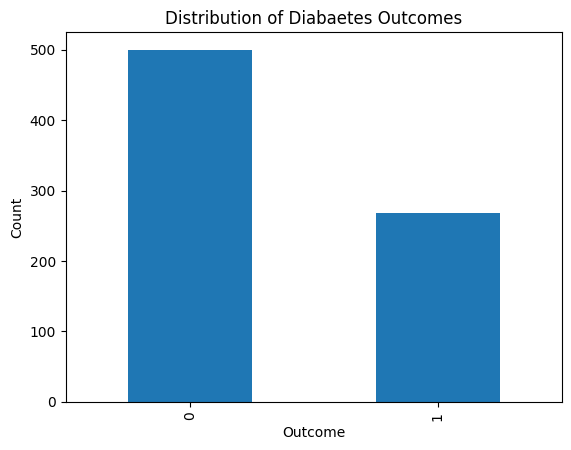

In [ ]:
#Display the number of flowers in each species
df["Outcome"].value_counts().plot(kind="bar")

#Add chart title
plt.title("Distribution of Diabaetes Outcomes")

#Add x-asis label
plt.xlabel("Outcome")

# Add y-axis label
plt.ylabel("Count")

# Display the chart
plt.show()

In [ ]:
# Create the SMOTE object
smote = SMOTE(random_state=42)

In [ ]:
# Apply SMOTE to balance the dataset
x_balanced, y_balanced = smote.fit_resample(x,y)

In [ ]:
# Display the new class distribution
print(y_balanced.value_counts())

Outcome
1    500
0    500
Name: count, dtype: int64


In [ ]:
# Create a dataframe containing the balanced target variable
balanced_df = pd.DataFrame(y_balanced, columns=["Outcome"])

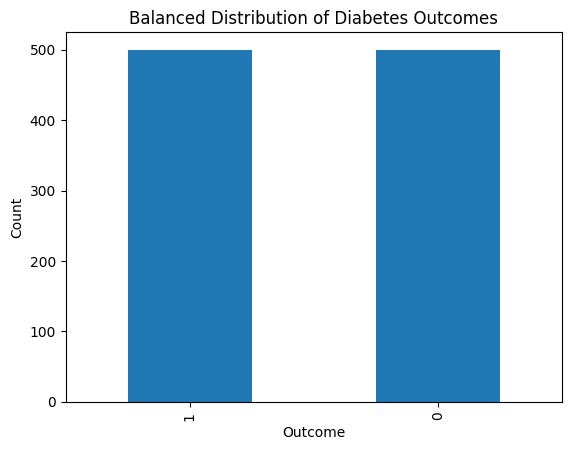

In [ ]:
# Plot the balanced distribution
balanced_df["Outcome"].value_counts().plot(kind="bar")

#Add chart titles
plt.title("Balanced Distribution of Diabetes Outcomes")

#Add x-axis label
plt.xlabel("Outcome")

#Add y-axis label
plt.ylabel("Count")

#Display the chart
plt.show()

In [ ]:
# Train-test split using the balanced data

x_train, x_test, y_train, y_test = train_test_split(x_balanced, y_balanced, test_size=0.2, random_state=42)

In [ ]:
# Create the KNN classifier
model = KNeighborsClassifier(n_neighbors=5)

In [ ]:
# Train the model using the training data
model.fit(x_train, y_train)

KNeighborsClassifier()

In [ ]:
# Predict diabetes outcomes for testing data
predictions = model.predict(x_test)

In [ ]:
# Calculate model accuracy
accuracy = accuracy_score(y_test, predictions)

In [ ]:
# Display the accuracy score
print("Accuracy:", accuracy)

Accuracy: 0.845


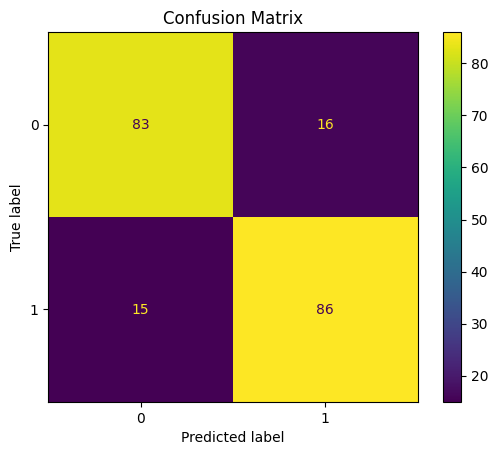

In [ ]:
# Display confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, predictions)

plt.title("Confusion Matrix")
plt.show()